# Julia for Simulation Analysis

Practical Julia habits for post-processing work: reproducible environments, what compile-time
latency is (and is not), memory discipline on laptop-scale machines, and measured
multithreading. Nothing here is Mera-specific dogma — these are the standard patterns of the
language, applied to snapshot analysis.

## 1. Environments: make every project reproducible

Julia's package manager pins exact versions per project. In a fresh directory:

```julia
julia> ]                       # enter package mode
(@v1.12) pkg> activate .       # this directory becomes the project
(myproject) pkg> add Mera CairoMakie
```

That writes `Project.toml`/`Manifest.toml`; anyone (including future you) reproduces the exact
stack with `] instantiate`. Start Julia with `julia --project=.` to use it.

## 2. Compile-time latency: pay once per session

Julia compiles functions the first time they run with a given argument type. The first
projection of a session takes seconds of compilation; the second is pure runtime:


In [1]:
# Example-data root. Point this at your own simulation folder, or set the
# MERA_EXAMPLES environment variable; every path below is built from it.
MERA_EXAMPLES = get(ENV, "MERA_EXAMPLES", "/Volumes/FASTStorage/Simulations/Mera-Tests");

using Mera, CairoMakie
CairoMakie.activate!()
BASE = MERA_EXAMPLES   # <-- change me
info = getinfo(100, joinpath(BASE, "RAMSES/spiral_clumps"), verbose=false)
gas  = gethydro(info, verbose=false, show_progress=false)
proj() = projection(gas, :sd; pxsize=[0.4, :kpc], verbose=false, show_progress=false)
t1 = @elapsed proj()      # includes compilation
t2 = @elapsed proj()      # pure runtime
println("first call: ", round(t1, digits=2), " s   second call: ", round(t2, digits=3), " s")


*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0



first call: 12.07

 s   second call: 0.042 s


Keep one session alive while you work (REPL, Jupyter, VS Code) instead of re-launching
`julia script.jl` per plot — relaunching pays the compile tax every time.

## 3. Your own loops are fast — write them

Custom per-cell analysis needs no vectorisation gymnastics. A plain loop over columns compiles
to native code; the one rule is to keep it in a **function** (globals are slow):


In [2]:
rho = getvar(gas, :rho, :g_cm3); T = getvar(gas, :T, :K); vol = getvar(gas, :volume, :cm3)
# mass-weighted mean temperature of dense gas — as an explicit loop
function mwT(rho, T, vol; thresh=1e-24)
    num = 0.0; den = 0.0
    @inbounds for i in eachindex(rho)
        rho[i] > thresh || continue
        m = rho[i] * vol[i]
        num += m * T[i]; den += m
    end
    return num / den
end
mwT(rho, T, vol)                                   # compile
t = @elapsed mwT(rho, T, vol)
println("mass-weighted T (ρ>1e-24 g/cm³): ", round(mwT(rho, T, vol), sigdigits=4),
        " K   —   ", length(rho), " cells in ", round(1e3 * t, digits=2), " ms")

mass-weighted T (ρ>1e-24 g/cm³): 67870.0

 K   —   590311 cells in 0.21 ms


## 4. Memory discipline on laptop-scale machines

The levers, in the order to reach for them:

1. **Load less**: `gethydro(info; lmax=…)` caps the refinement level;
   `xrange/yrange/zrange` load a spatial window (applied while reading — the full box never
   materialises).
2. **Select variables**: `gethydro(info, [:rho, :p])` reads only what you need.
3. **One snapshot at a time**: in loops over outputs, let each object go out of scope before
   loading the next (the `timeseries` helper does this for you, with `GC.gc()` between
   snapshots).
4. **Watch it**: `usedmemory(gas)` for objects, `storageoverview(info)` before loading.


In [3]:
small = gethydro(info; lmax=6, xrange=[-8., 8.], yrange=[-8., 8.], zrange=[-2., 2.],
                 center=[:bc], range_unit=:kpc, vars=[:rho], verbose=false, show_progress=false)
println(length(small.data), " cells (windowed, lmax=6, :rho only)  vs  ",
        length(gas.data), " full (lmax=", gas.lmax, ")")
usedmemory(small)

576 cells (windowed, lmax=6, :rho only)  vs  

590311 full (lmax=7)
Memory used: 

481.366 KB


(481.3662109375, "KB")

## 5. Multithreading, measured

Start Julia with threads (`julia -t 8` or `JULIA_NUM_THREADS=8`) and Mera's heavy paths
(reading, projections) use them automatically; every such function takes `max_threads=` to
throttle a single call. Three rules of thumb:

- results are **independent of the thread count** (per-thread buffers, summed at the end);
- **threading pays where the compute is.** A light call on a small dataset is dominated by its
  serial parts (column access, setup) and shows little gain — an axis-aligned projection of this
  small fixture runs in ~0.6 s regardless of threads. Give the threads real work and the
  picture changes: below, the compute-heavy off-axis `:exact` deposit kernel on the same data;
- BLAS keeps its own thread pool — keep `Julia threads × BLAS threads` within your core budget.

Measured on this machine (8 Julia threads; **illustrative, not a benchmark** — your times will
differ):


Julia threads: 4


max_threads=1  105.42 s   speedup ×1.0
max_threads=2  75.87 s   speedup ×1.39
max_threads=4  52.57 s   speedup ×2.01
max_threads=8  52.54 s   speedup ×2.01


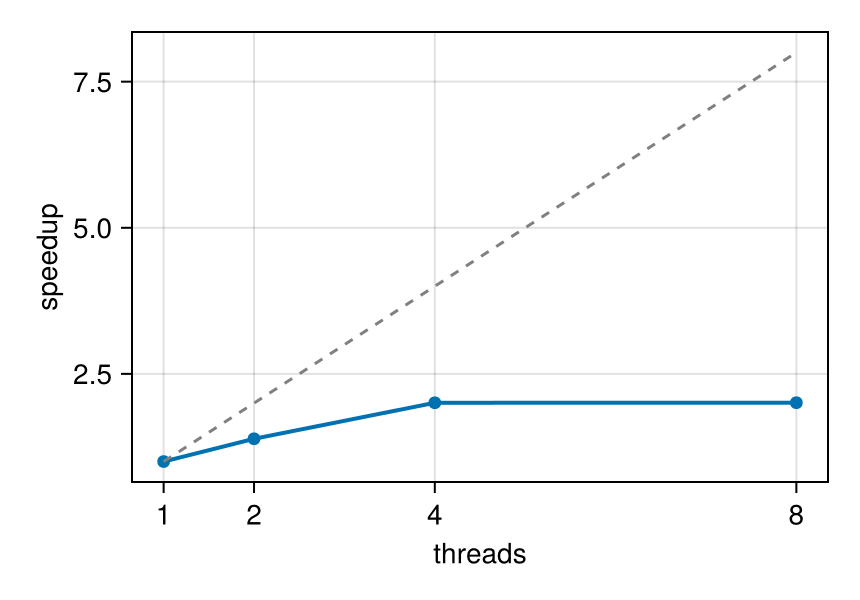

In [4]:
println("Julia threads: ", Threads.nthreads())
# compute-heavy workload: off-axis projection with the analytic :exact deposit kernel
heavy(nt) = projection(gas, :sd; inclination=60, azimuth=30, pxsize=[0.05, :kpc],
                       binning=:exact, max_threads=nt, verbose=false, show_progress=false)
heavy(1)                                             # compile once
nts = [1, 2, 4, 8]
times = [minimum(@elapsed(heavy(nt)) for _ in 1:2) for nt in nts]
for (nt, t) in zip(nts, times)
    println(rpad("max_threads=$nt", 15), round(t, digits=2), " s   speedup ×",
            round(times[1] / t, digits=2))
end
fig = Figure(size=(430, 300))
ax = Axis(fig[1, 1], xlabel="threads", ylabel="speedup", xticks=nts)
lines!(ax, nts, times[1] ./ times, linewidth=2); scatter!(ax, nts, times[1] ./ times)
lines!(ax, nts, Float64.(nts), linestyle=:dash, color=:gray)   # ideal
fig

The dashed line is ideal scaling; the gap to it is the serial fraction. Throttle
individual calls (`max_threads=4`) when you run several analyses at once or share the machine.
The examples throughout these docs use at most 8 threads — treat that as a sensible laptop
ceiling, not a recommendation to buy more cores.

## 6. Where to go next

- [First Steps](00_multi_FirstSteps.md) — the full introductory tutorial.
- [Coming from Other Analysis Tools](switching_to_mera.md) — concept mapping + one complete workflow.
- [Migration cheat sheet](quickreference/02_migrators.md) — Python/MATLAB/IDL syntax side by side.
- [Multi-Threading guide](multi-threading/multi-threading_intro.md) — the full threading reference.
